In [1]:
from utils import *
NOTEBOOK_ID = '12'

In [2]:
CONSTANS = 'MLKQESNDIGSGENNRARPCDTCRSNACTVYCHADSAYLCMSCDAQVHSANRVASRHKRVRVCESCERAPAAFLCEADDASLCTACDSEVHSANPLARRHQRVPILPISGNSFSSMTTTHHQSEKTMTDPEKRLVVDQEEGEEGDKDAKEVASWLFPNSDKNNNNQNNGLLFSDEYLNLVDYNSSMDYKFTGEYSQHQQNCSVPQTSYGGDRVVPLKLEESRGHQCHNQQNFQFNIKYGSSGTHYNDNGSINHNAYISSMETGVVPESTACVTTASHPRTPKGTVEQQPDPASQMITVTQLSPMDREARVLRYREKRKTRKFEKTIRYASRKAYAEIRPRVNGRFAKREIEAEEQGFNTMLMYNTGYGIVPSF'
SLICE_SEQS = False
if SLICE_SEQS:
    constans_slices = create_protein_tiles(CONSTANS,tile_size=53,overlap_size=52)
    pd.DataFrame(constans_slices,columns=['AAseq']).to_csv(f'{CONSTANS_DIR}/constans_slices.csv',index=False)

    constans_slices = create_protein_tiles(CONSTANS,tile_size=40,overlap_size=39)
    pd.DataFrame(constans_slices,columns=['AAseq']).to_csv(f'{CONSTANS_DIR}/constans_slices_40.csv',index=False)

In [3]:
RUN_METAPREDICT = False
if RUN_METAPREDICT:
    os.system('metapredict-predict-disorder ../01-input/01-METADATA/CONSTANS.faa -d cuda')

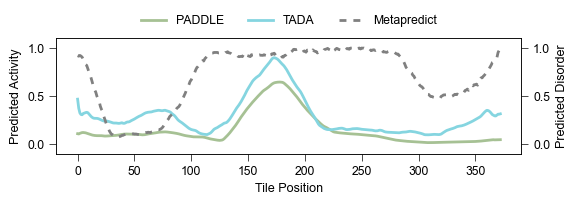

In [4]:
tada_df = pd.read_pickle(f'{INFERENCE_DIR}/02-TADA/constans_TADA_prediction.pkl')
paddle_df = pd.read_csv(f'{INFERENCE_DIR}/01-PADDLE/constans_PADDLE.csv')
paddle_df['PADDLE_zscore_scaled'] = MinMaxScaler().fit_transform(paddle_df['PADDLE_zscore'].to_numpy().reshape(-1,1))
tada_df['y_test_hat_scaled'] = MinMaxScaler().fit_transform(tada_df['y_test_hat'].to_numpy().reshape(-1,1))

modelA_profile = tile_to_residue_profile(tada_df['y_test_hat_scaled'].to_list(), tile_size=40, seq_len=len(CONSTANS))
modelB_profile = tile_to_residue_profile(paddle_df['PADDLE_zscore_scaled'].to_list(), tile_size=53, seq_len=len(CONSTANS))
disorder_pred = pd.read_csv(f'{CONSTANS_DIR}/CONSTANS_disorder_scores.csv',header=None).drop(columns=[0,1]).T.to_numpy()

fig, ax1 = plt.subplots(figsize=(6, 1.5))
ax1.plot(modelB_profile, label='PADDLE', linewidth=2, color='#a6c194')
ax1.plot(modelA_profile, label='TADA', linewidth=2, color='#85d5e0')
ax1.set_xlabel('Tile Position')
ax1.set_ylabel('Predicted Activity')
ax1.set_ylim(-0.1,1.1)
lines1, labels1 = ax1.get_legend_handles_labels()

ax2 = ax1.twinx()
ax2.plot(disorder_pred, label='Metapredict', linewidth=2, color='gray',linestyle=(0,(2.5,2.5)))
ax2.set_ylabel('Predicted Disorder')
ax2.set_ylim(-0.1,1.1)
ax2.yaxis.set_major_locator(MultipleLocator(0.5))
lines2, labels2 = ax2.get_legend_handles_labels()
lines = lines1 + lines2
labels = labels1 + labels2
ax1.legend(lines, labels, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.3),ncol=3)

if SAVE_FIGURES:
    plt.savefig(f'{FIGURE_DIR}/{NOTEBOOK_ID}-CONSTANS_predictions.svg',**FIG_PARAMS)